# 05 — Preparazione Dati di Training per ModernBERT

Questo notebook prepara i dataset di training e test per due modelli **ModernBERT**:

| Modello | Task | Input | Output |
|---------|------|-------|--------|
| **Model 1** | Multiclass classification | Descrizione progetto | Tipo di applicazione AI (es. healthcare_ai, fintech) |
| **Model 2** | Multilabel classification | Descrizione progetto | Tecniche/strumenti AI (es. computer_vision, nlp, deep_learning) |

**Fonte dati**: `eu_ai_act_risk_register_2026.csv` (42 sistemi AI dal registro EU AI Act)  
**Augmentation**: template-based (parafrasi strutturali) applicata solo al train set  
**Split**: 90% train / 10% test (split pre-augmentation per evitare data leakage)

## 1. Setup e Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from pathlib import Path
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

In [2]:
# Dataset principale per il training
df_eu = pd.read_csv(RAW_DIR / 'eu_ai_act_risk_register_2026.csv')

# Dataset secondario — solo per EDA comparativa (scartato per training)
df_agentic = pd.read_csv(RAW_DIR / 'Large_Agentic_AI_Applications_2025.csv')

print(f'EU AI Act Risk Register: {df_eu.shape[0]} righe, {df_eu.shape[1]} colonne')
print(f'Large Agentic AI Applications: {df_agentic.shape[0]} righe, {df_agentic.shape[1]} colonne')

EU AI Act Risk Register: 42 righe, 28 colonne
Large Agentic AI Applications: 10000 righe, 8 colonne


## 2. EDA — EU AI Act Risk Register

Questo dataset contiene 42 sistemi AI classificati secondo il regolamento EU AI Act, con informazioni su rischio, dominio applicativo, use case, e compliance.

In [3]:
# Profiling generale
info_data = []
for col in df_eu.columns:
    info_data.append({
        'Colonna': col,
        'Tipo': str(df_eu[col].dtype),
        'Non-Null': df_eu[col].notna().sum(),
        'Null (%)': f"{df_eu[col].isna().mean() * 100:.1f}%",
        'Unici': df_eu[col].nunique()
    })

info_df = pd.DataFrame(info_data)
info_df

,Colonna,Tipo,Non-Null,Null (%),Unici
0,ai_system_name,str,42,0.0%,42
1,company_example,str,42,0.0%,42
2,country_of_origin,str,42,0.0%,20
3,risk_tier,str,42,0.0%,5
4,article_reference,str,37,11.9%,30
5,domain,str,42,0.0%,24
6,use_case,str,42,0.0%,42
7,compliance_deadline,str,37,11.9%,4
8,compliance_status,str,42,0.0%,7
9,fine_tier_eur,str,37,11.9%,5


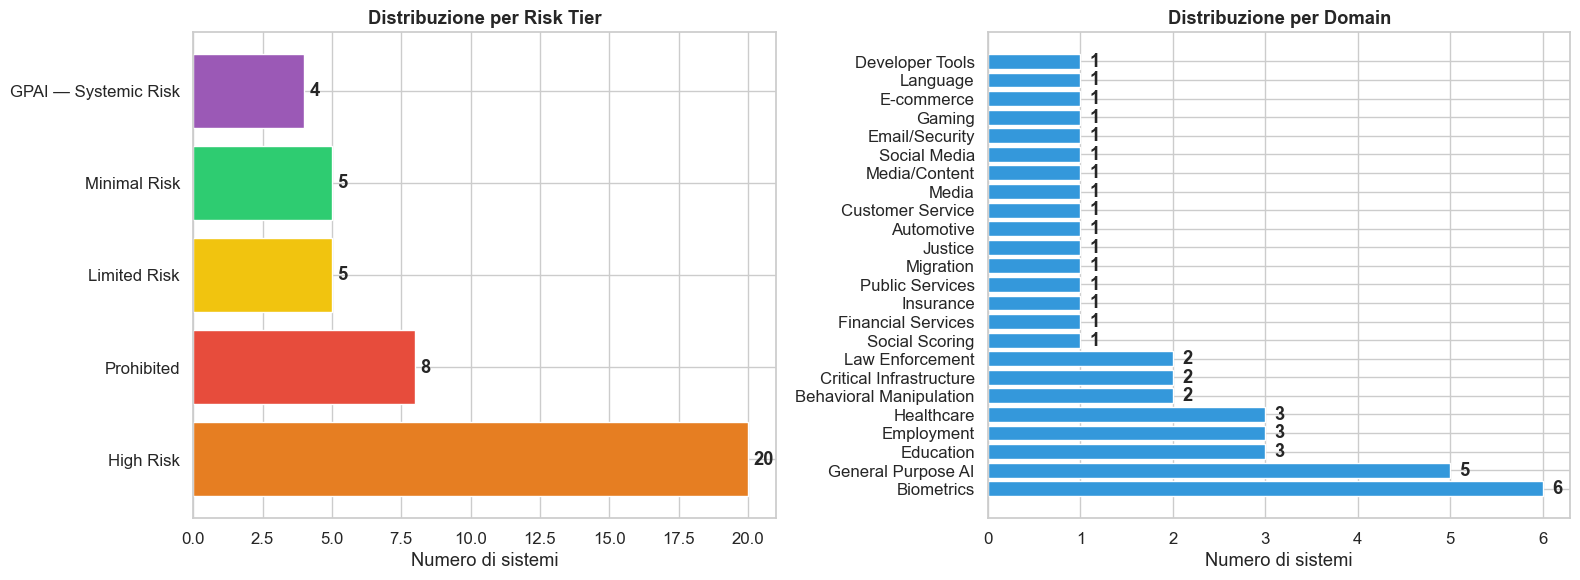

In [4]:
# Distribuzione risk_tier
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

risk_counts = df_eu['risk_tier'].value_counts()
colors_risk = {'Prohibited': '#e74c3c', 'High Risk': '#e67e22', 'Limited Risk': '#f1c40f',
               'Minimal Risk': '#2ecc71', 'GPAI — Systemic Risk': '#9b59b6'}
risk_colors = [colors_risk.get(r, '#3498db') for r in risk_counts.index]

axes[0].barh(risk_counts.index, risk_counts.values, color=risk_colors)
axes[0].set_xlabel('Numero di sistemi')
axes[0].set_title('Distribuzione per Risk Tier', fontweight='bold')
for i, v in enumerate(risk_counts.values):
    axes[0].text(v + 0.2, i, str(v), va='center', fontweight='bold')

# Distribuzione domain
domain_counts = df_eu['domain'].value_counts()
axes[1].barh(domain_counts.index, domain_counts.values, color='#3498db')
axes[1].set_xlabel('Numero di sistemi')
axes[1].set_title('Distribuzione per Domain', fontweight='bold')
for i, v in enumerate(domain_counts.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

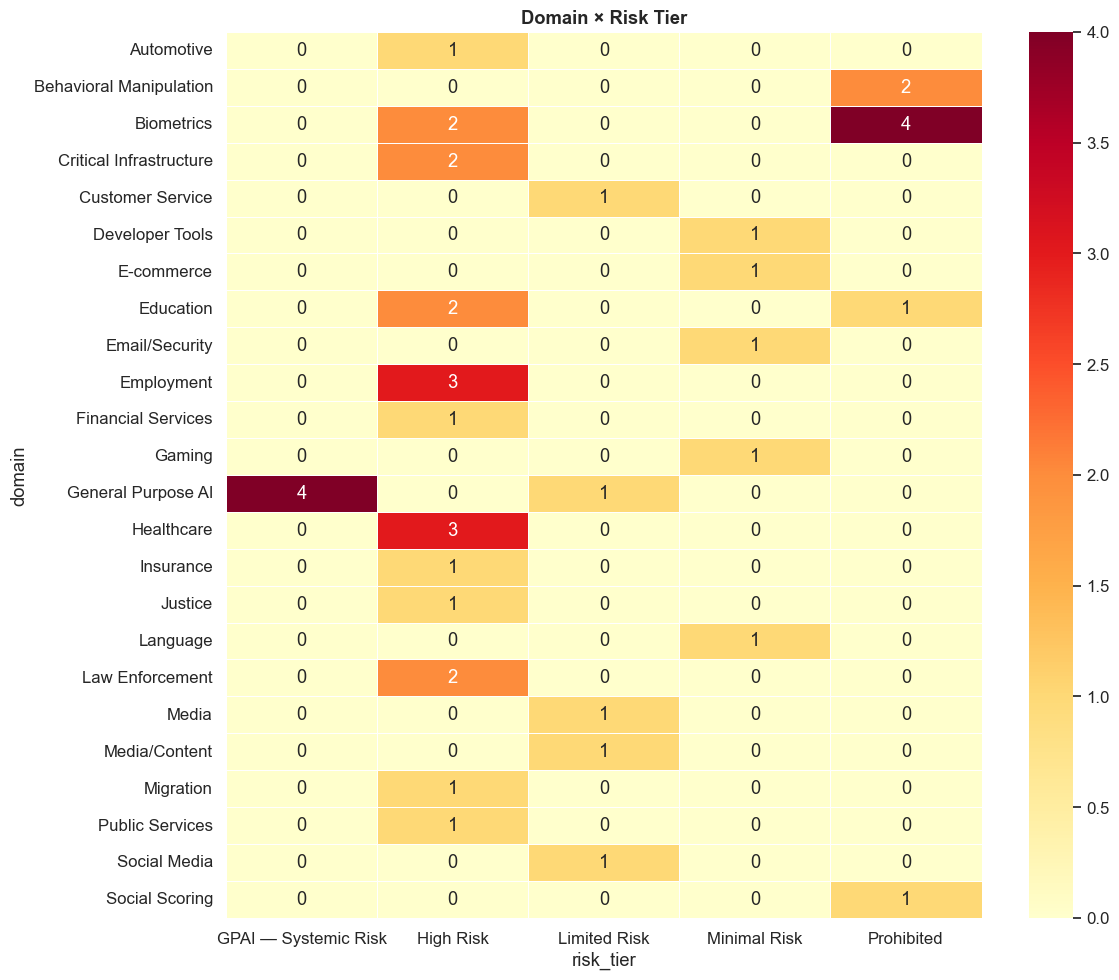

In [5]:
# Crosstab domain × risk_tier
ct = pd.crosstab(df_eu['domain'], df_eu['risk_tier'])

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Domain × Risk Tier', fontweight='bold')
plt.tight_layout()
plt.show()

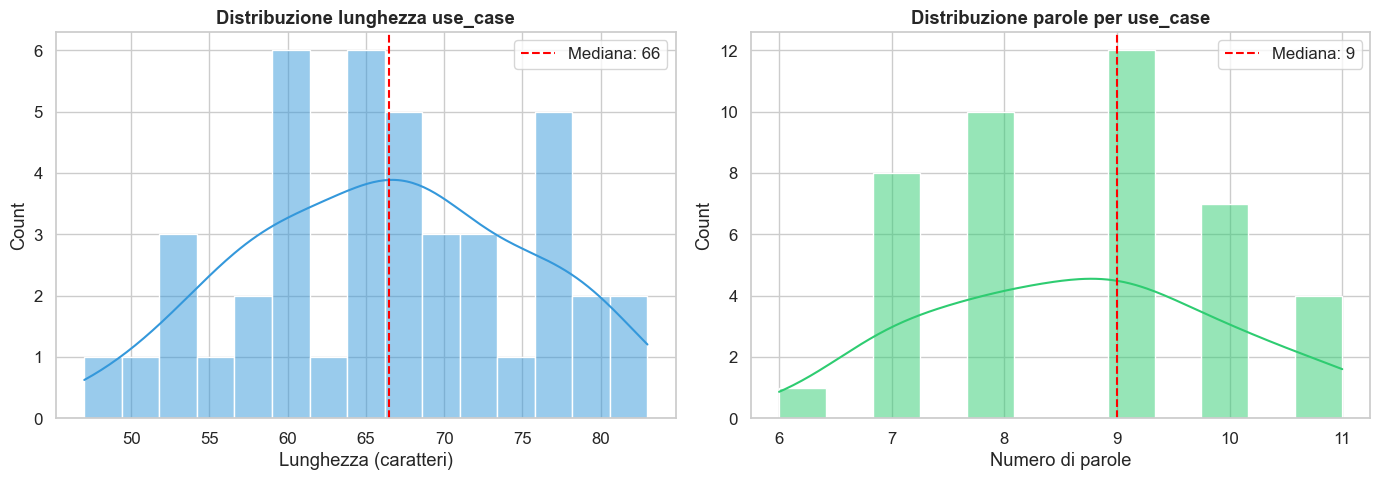

Lunghezza media: 66 caratteri, 9 parole
Range: 47–83 caratteri


In [6]:
# Analisi testi use_case
df_eu['use_case_len'] = df_eu['use_case'].str.len()
df_eu['use_case_words'] = df_eu['use_case'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_eu['use_case_len'], bins=15, kde=True, ax=axes[0], color='#3498db')
axes[0].set_xlabel('Lunghezza (caratteri)')
axes[0].set_title('Distribuzione lunghezza use_case', fontweight='bold')
axes[0].axvline(df_eu['use_case_len'].median(), color='red', linestyle='--', label=f"Mediana: {df_eu['use_case_len'].median():.0f}")
axes[0].legend()

sns.histplot(df_eu['use_case_words'], bins=12, kde=True, ax=axes[1], color='#2ecc71')
axes[1].set_xlabel('Numero di parole')
axes[1].set_title('Distribuzione parole per use_case', fontweight='bold')
axes[1].axvline(df_eu['use_case_words'].median(), color='red', linestyle='--', label=f"Mediana: {df_eu['use_case_words'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Lunghezza media: {df_eu['use_case_len'].mean():.0f} caratteri, {df_eu['use_case_words'].mean():.0f} parole")
print(f"Range: {df_eu['use_case_len'].min()}–{df_eu['use_case_len'].max()} caratteri")

In [7]:
# Panoramica dei 42 sistemi AI
display_cols = ['ai_system_name', 'domain', 'risk_tier', 'use_case', 'sector']
df_eu[display_cols].style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
)

,ai_system_name,domain,risk_tier,use_case,sector
0,Social Credit Scoring System,Social Scoring,Prohibited,Scoring individuals based on social behavior and trustworthiness,Government/Finance
1,Subliminal Manipulation Engine,Behavioral Manipulation,Prohibited,Using subliminal techniques to distort human behavior against their will,Political/Advertising
2,Real-Time Public Facial Recognition,Biometrics,Prohibited,Real-time remote biometric identification in public spaces by private entities,Law Enforcement/Security
3,Vulnerability Exploitation AI,Behavioral Manipulation,Prohibited,"Exploiting age, disability, or socioeconomic vulnerability to distort behavior",Advertising/Retail
4,Workplace Emotion Recognition System,Biometrics,Prohibited,Inferring emotions of employees in workplace settings,HR/Enterprise
5,Classroom Emotion Surveillance,Education,Prohibited,Emotion recognition systems deployed in educational institutions,Education
6,Biometric Characteristic Inference AI,Biometrics,Prohibited,"Inferring race, political opinion, religion, sexual orientation from biometrics",Security/Law Enforcement
7,Untargeted Facial Recognition Scraping,Biometrics,Prohibited,Mass scraping of internet/CCTV images to build facial recognition databases,Law Enforcement
8,Biometric Verification System (Airport),Biometrics,High Risk,Biometric verification of travellers at border control,Travel/Security
9,Live Biometric Identification (Law Enforcement),Biometrics,High Risk,Post-facto biometric identification for law enforcement investigations,Law Enforcement


## 3. EDA — Large Agentic AI Applications (analisi esplorativa)

Analizziamo questo dataset per documentare perché **non viene utilizzato per il training**.

In [8]:
# Profiling
info_data_ag = []
for col in df_agentic.columns:
    info_data_ag.append({
        'Colonna': col,
        'Tipo': str(df_agentic[col].dtype),
        'Non-Null': df_agentic[col].notna().sum(),
        'Null (%)': f"{df_agentic[col].isna().mean() * 100:.1f}%",
        'Unici': df_agentic[col].nunique()
    })

pd.DataFrame(info_data_ag)

,Colonna,Tipo,Non-Null,Null (%),Unici
0,Industry,str,10000,0.0%,10
1,Application Area,str,10000,0.0%,10
2,AI Agent Name,str,10000,0.0%,10
3,Task Description,str,10000,0.0%,10
4,Technology Stack,str,10000,0.0%,9
5,Outcome Metrics,str,10000,0.0%,10
6,Deployment Year,int64,10000,0.0%,3
7,Geographical Region,str,10000,0.0%,6


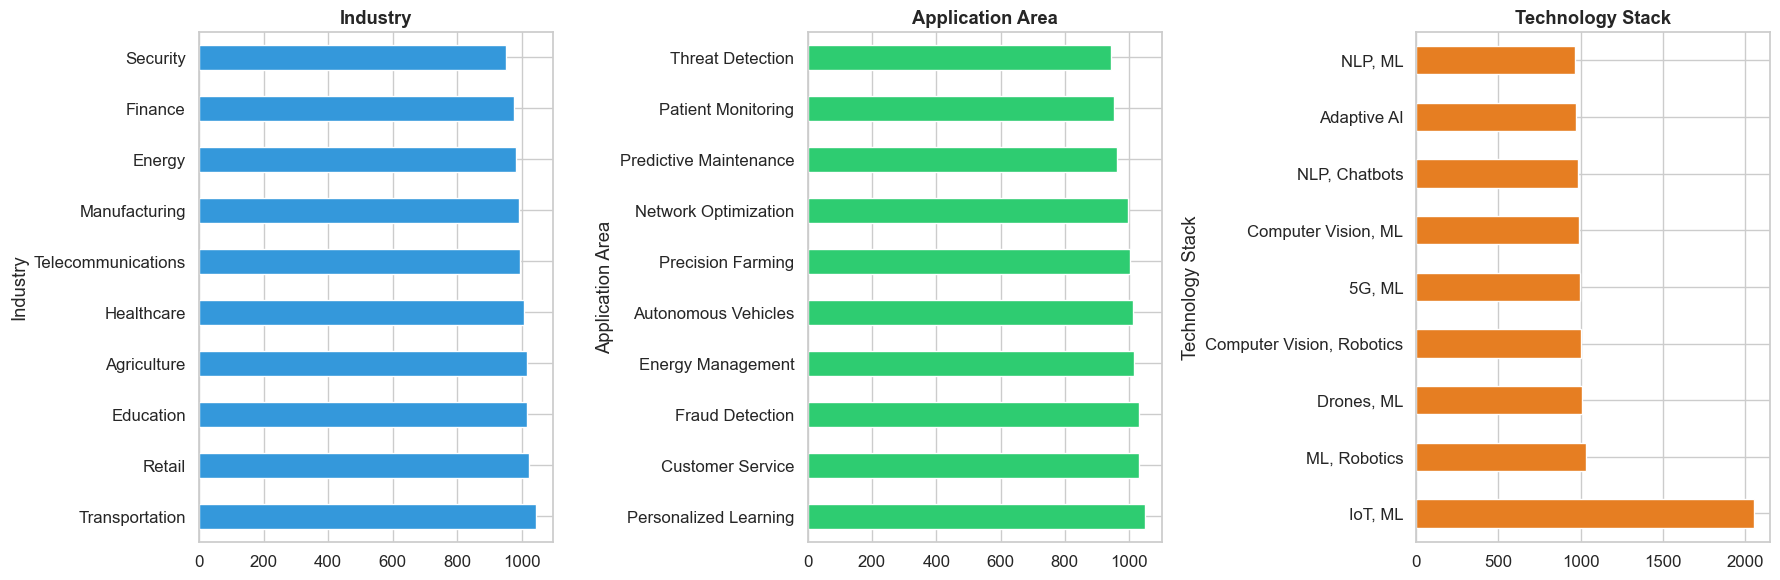

In [9]:
# Distribuzioni principali
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

df_agentic['Industry'].value_counts().plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Industry', fontweight='bold')

df_agentic['Application Area'].value_counts().plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Application Area', fontweight='bold')

df_agentic['Technology Stack'].value_counts().plot(kind='barh', ax=axes[2], color='#e67e22')
axes[2].set_title('Technology Stack', fontweight='bold')

plt.tight_layout()
plt.show()

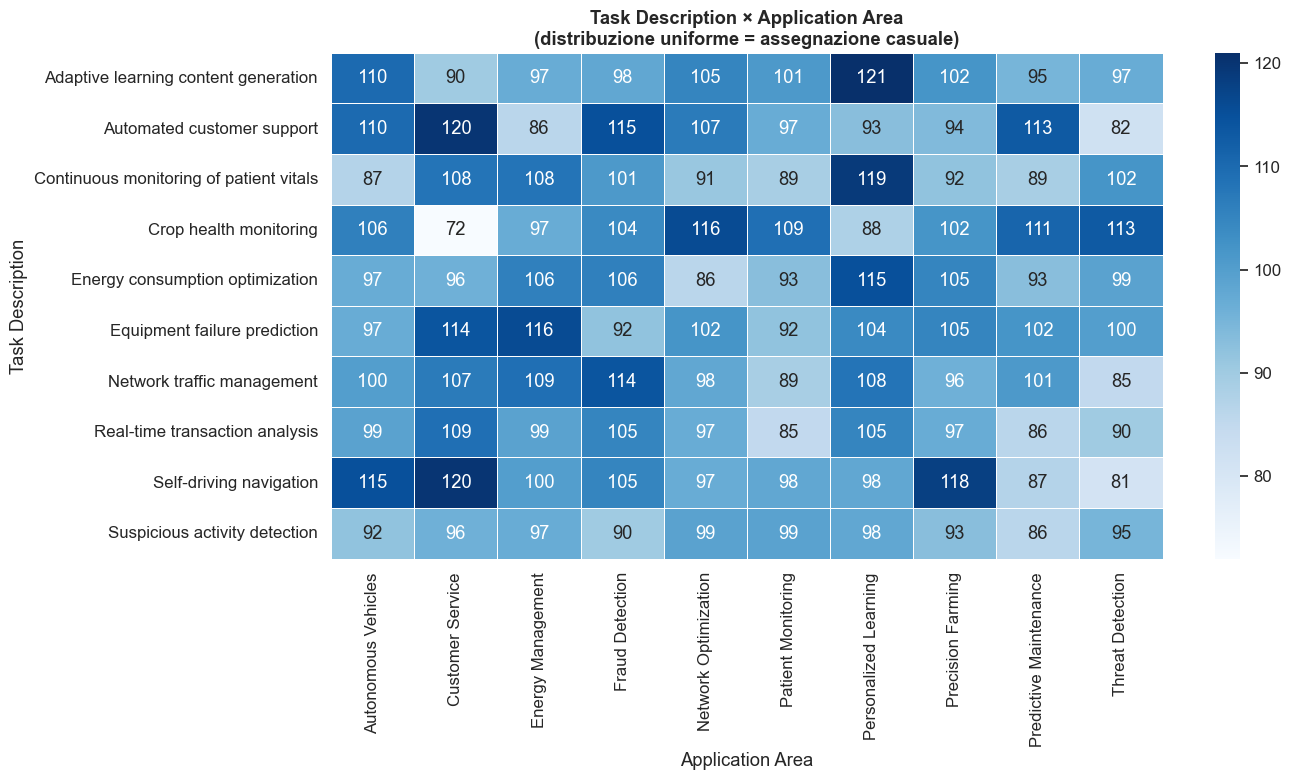

Chi-quadrato: 77.85, p-value: 0.5786
p-value > 0.05 → le colonne sono statisticamente indipendenti (assegnazione casuale)

→ Dataset scartato per il training: le label non hanno relazione semantica con le descrizioni.


In [10]:
# PROBLEMA QUALITÀ: le colonne sono assegnate casualmente
# Se Task Description fosse coerente con Application Area, ci aspetteremmo una distribuzione diagonale.
# Invece osserviamo distribuzione uniforme → assegnazione random.

ct_agentic = pd.crosstab(df_agentic['Task Description'], df_agentic['Application Area'])

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(ct_agentic, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Task Description × Application Area\n(distribuzione uniforme = assegnazione casuale)', fontweight='bold')
plt.tight_layout()
plt.show()

# Verifica statistica: chi-quadrato
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(ct_agentic)
print(f'Chi-quadrato: {chi2:.2f}, p-value: {p_value:.4f}')
print(f'p-value > 0.05 → le colonne sono statisticamente indipendenti (assegnazione casuale)')
print(f'\n→ Dataset scartato per il training: le label non hanno relazione semantica con le descrizioni.')

### Conclusione EDA Dataset 2

Il dataset `Large_Agentic_AI_Applications_2025.csv` presenta **colonne assegnate casualmente**: le `Task Description` non corrispondono semanticamente alle `Application Area` o `Technology Stack` associate. Il test chi-quadrato conferma l'indipendenza statistica tra le colonne. Questo dataset **non è utilizzabile per il training** senza una riassegnazione completa delle label.

Si procede con il solo dataset EU AI Act Risk Register (42 sistemi) + data augmentation.

## 4. Definizione Tassonomia delle Label

In [11]:
# ============================================================
# MODEL 1 — Multiclass: tipo di applicazione AI
# Mapping da domain (originale) → label normalizzata
# ============================================================

DOMAIN_TO_LABEL = {
    'Biometrics': 'biometrics',
    'Behavioral Manipulation': 'behavioral_manipulation',
    'Social Scoring': 'social_scoring',
    'Critical Infrastructure': 'critical_infrastructure',
    'Education': 'education_ai',
    'Employment': 'employment_ai',
    'Financial Services': 'fintech',
    'Insurance': 'fintech',
    'Public Services': 'public_services',
    'Law Enforcement': 'law_enforcement',
    'Migration': 'law_enforcement',
    'Justice': 'legal_ai',
    'Healthcare': 'healthcare_ai',
    'Automotive': 'autonomous_driving',
    'General Purpose AI': 'general_purpose_ai',
    'Customer Service': 'conversational_ai',
    'Media': 'generative_ai',
    'Media/Content': 'generative_ai',
    'Social Media': 'recommender_systems',
    'E-commerce': 'recommender_systems',
    'Email/Security': 'cybersecurity',
    'Gaming': 'gaming_ai',
    'Language': 'nlp_ai',
    'Developer Tools': 'code_ai',
}

df_eu['app_type'] = df_eu['domain'].map(DOMAIN_TO_LABEL)

# Verifica copertura
unmapped = df_eu[df_eu['app_type'].isna()]['domain'].unique()
if len(unmapped) > 0:
    print(f'⚠ Domini non mappati: {unmapped}')
else:
    print(f'✓ Tutti i {df_eu["domain"].nunique()} domini mappati → {df_eu["app_type"].nunique()} classi finali')

print(f'\nDistribuzione classi Model 1:')
print(df_eu['app_type'].value_counts().to_string())

✓ Tutti i 24 domini mappati → 20 classi finali

Distribuzione classi Model 1:
app_type
biometrics                 6
general_purpose_ai         5
education_ai               3
employment_ai              3
law_enforcement            3
healthcare_ai              3
behavioral_manipulation    2
critical_infrastructure    2
fintech                    2
generative_ai              2
recommender_systems        2
social_scoring             1
public_services            1
legal_ai                   1
autonomous_driving         1
conversational_ai          1
cybersecurity              1
gaming_ai                  1
nlp_ai                     1
code_ai                    1


In [12]:
# ============================================================
# MODEL 2 — Multilabel: tecniche/strumenti AI
# Mapping manuale basato su use_case e dominio
# ============================================================

SYSTEM_TO_TECHNIQUES = {
    'Social Credit Scoring System': ['machine_learning', 'data_mining', 'social_network_analysis'],
    'Subliminal Manipulation Engine': ['nlp', 'deep_learning', 'behavioral_analytics'],
    'Real-Time Public Facial Recognition': ['computer_vision', 'deep_learning', 'biometrics'],
    'Vulnerability Exploitation AI': ['machine_learning', 'behavioral_analytics', 'nlp'],
    'Workplace Emotion Recognition System': ['computer_vision', 'deep_learning', 'sentiment_analysis'],
    'Classroom Emotion Surveillance': ['computer_vision', 'deep_learning', 'sentiment_analysis'],
    'Biometric Characteristic Inference AI': ['computer_vision', 'deep_learning', 'biometrics'],
    'Untargeted Facial Recognition Scraping': ['computer_vision', 'deep_learning', 'biometrics', 'data_mining'],
    'Biometric Verification System (Airport)': ['computer_vision', 'biometrics', 'deep_learning'],
    'Live Biometric Identification (Law Enforcement)': ['computer_vision', 'biometrics', 'deep_learning'],
    'Smart Grid AI Management System': ['machine_learning', 'iot', 'time_series_analysis', 'optimization'],
    'Water Treatment AI Monitor': ['machine_learning', 'iot', 'anomaly_detection', 'time_series_analysis'],
    'AI Admission Scoring System': ['machine_learning', 'nlp', 'ranking_algorithms'],
    'AI Student Performance Prediction': ['machine_learning', 'predictive_analytics', 'data_mining'],
    'AI CV Screening & Recruitment Tool': ['nlp', 'machine_learning', 'ranking_algorithms'],
    'AI Employee Monitoring & Productivity Scoring': ['machine_learning', 'behavioral_analytics', 'time_series_analysis'],
    'AI Gig Worker Task Allocation System': ['machine_learning', 'optimization', 'reinforcement_learning'],
    'AI Credit Scoring System': ['machine_learning', 'predictive_analytics', 'data_mining'],
    'AI Insurance Risk Assessment': ['machine_learning', 'predictive_analytics', 'data_mining'],
    'Social Benefit Eligibility AI': ['machine_learning', 'nlp', 'decision_systems'],
    'Predictive Policing System': ['machine_learning', 'predictive_analytics', 'geospatial_analysis'],
    'AI Lie Detection / Credibility Assessment': ['computer_vision', 'nlp', 'sentiment_analysis'],
    'AI Asylum Application Risk Classifier': ['nlp', 'machine_learning', 'decision_systems'],
    'AI Legal Research & Case Outcome Predictor': ['nlp', 'deep_learning', 'predictive_analytics'],
    'AI Diagnostic Imaging System (Radiology)': ['computer_vision', 'deep_learning', 'medical_imaging'],
    'AI Clinical Decision Support System': ['nlp', 'machine_learning', 'knowledge_graphs', 'decision_systems'],
    'AI Mental Health Triage System': ['nlp', 'deep_learning', 'sentiment_analysis'],
    'Autonomous Vehicle Level 3+ AI': ['computer_vision', 'deep_learning', 'reinforcement_learning', 'sensor_fusion'],
    'ChatGPT / Claude / Gemini (Consumer)': ['nlp', 'deep_learning', 'transformer', 'generative_ai'],
    'AI Customer Service Chatbot': ['nlp', 'deep_learning', 'chatbot'],
    'AI-Generated News Content Tool': ['nlp', 'deep_learning', 'generative_ai'],
    'Deepfake Detection & Generation Platform': ['computer_vision', 'deep_learning', 'generative_ai', 'gan'],
    'AI Recommendation Algorithm (Social Media)': ['deep_learning', 'recommender_systems', 'behavioral_analytics'],
    'AI Spam Filter': ['nlp', 'machine_learning', 'anomaly_detection'],
    'AI-Enabled Video Game NPC': ['reinforcement_learning', 'deep_learning', 'generative_ai'],
    'AI Product Recommendation Engine': ['deep_learning', 'recommender_systems', 'collaborative_filtering'],
    'AI Translation Tool': ['nlp', 'deep_learning', 'transformer'],
    'AI Code Assistant': ['nlp', 'deep_learning', 'transformer', 'generative_ai'],
    'GPT-4 / GPT-4o (API)': ['nlp', 'deep_learning', 'transformer', 'generative_ai'],
    'Gemini Ultra / Gemini 1.5 Pro': ['nlp', 'deep_learning', 'transformer', 'generative_ai', 'computer_vision'],
    'Claude 3.5 / Claude Sonnet 4': ['nlp', 'deep_learning', 'transformer', 'generative_ai'],
    'Llama 3 / Llama 4 (Open Source)': ['nlp', 'deep_learning', 'transformer', 'generative_ai'],
}

# Assegna le tecniche
df_eu['techniques'] = df_eu['ai_system_name'].map(SYSTEM_TO_TECHNIQUES)

# Verifica copertura
unmapped_sys = df_eu[df_eu['techniques'].isna()]['ai_system_name'].tolist()
if unmapped_sys:
    print(f'⚠ Sistemi non mappati: {unmapped_sys}')
else:
    all_techniques = sorted(set(t for techs in df_eu['techniques'] for t in techs))
    print(f'✓ Tutti i 42 sistemi mappati → {len(all_techniques)} tecniche uniche')
    print(f'\nTecniche: {all_techniques}')

✓ Tutti i 42 sistemi mappati → 27 tecniche uniche

Tecniche: ['anomaly_detection', 'behavioral_analytics', 'biometrics', 'chatbot', 'collaborative_filtering', 'computer_vision', 'data_mining', 'decision_systems', 'deep_learning', 'gan', 'generative_ai', 'geospatial_analysis', 'iot', 'knowledge_graphs', 'machine_learning', 'medical_imaging', 'nlp', 'optimization', 'predictive_analytics', 'ranking_algorithms', 'recommender_systems', 'reinforcement_learning', 'sensor_fusion', 'sentiment_analysis', 'social_network_analysis', 'time_series_analysis', 'transformer']


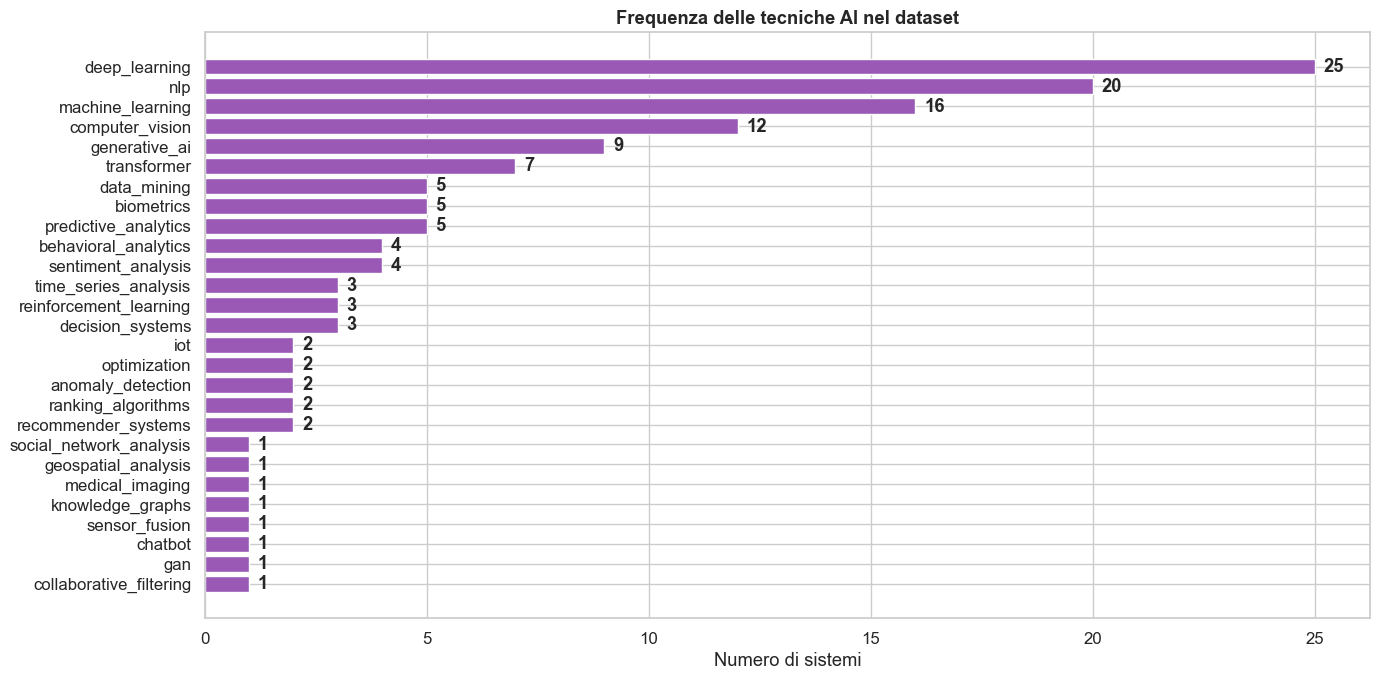

In [13]:
# Visualizzazione distribuzione tecniche
tech_counter = Counter(t for techs in df_eu['techniques'] for t in techs)
tech_df = pd.DataFrame(tech_counter.most_common(), columns=['Tecnica', 'Frequenza'])

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(tech_df['Tecnica'][::-1], tech_df['Frequenza'][::-1], color='#9b59b6')
ax.set_xlabel('Numero di sistemi')
ax.set_title('Frequenza delle tecniche AI nel dataset', fontweight='bold')
for i, v in enumerate(tech_df['Frequenza'][::-1]):
    ax.text(v + 0.2, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

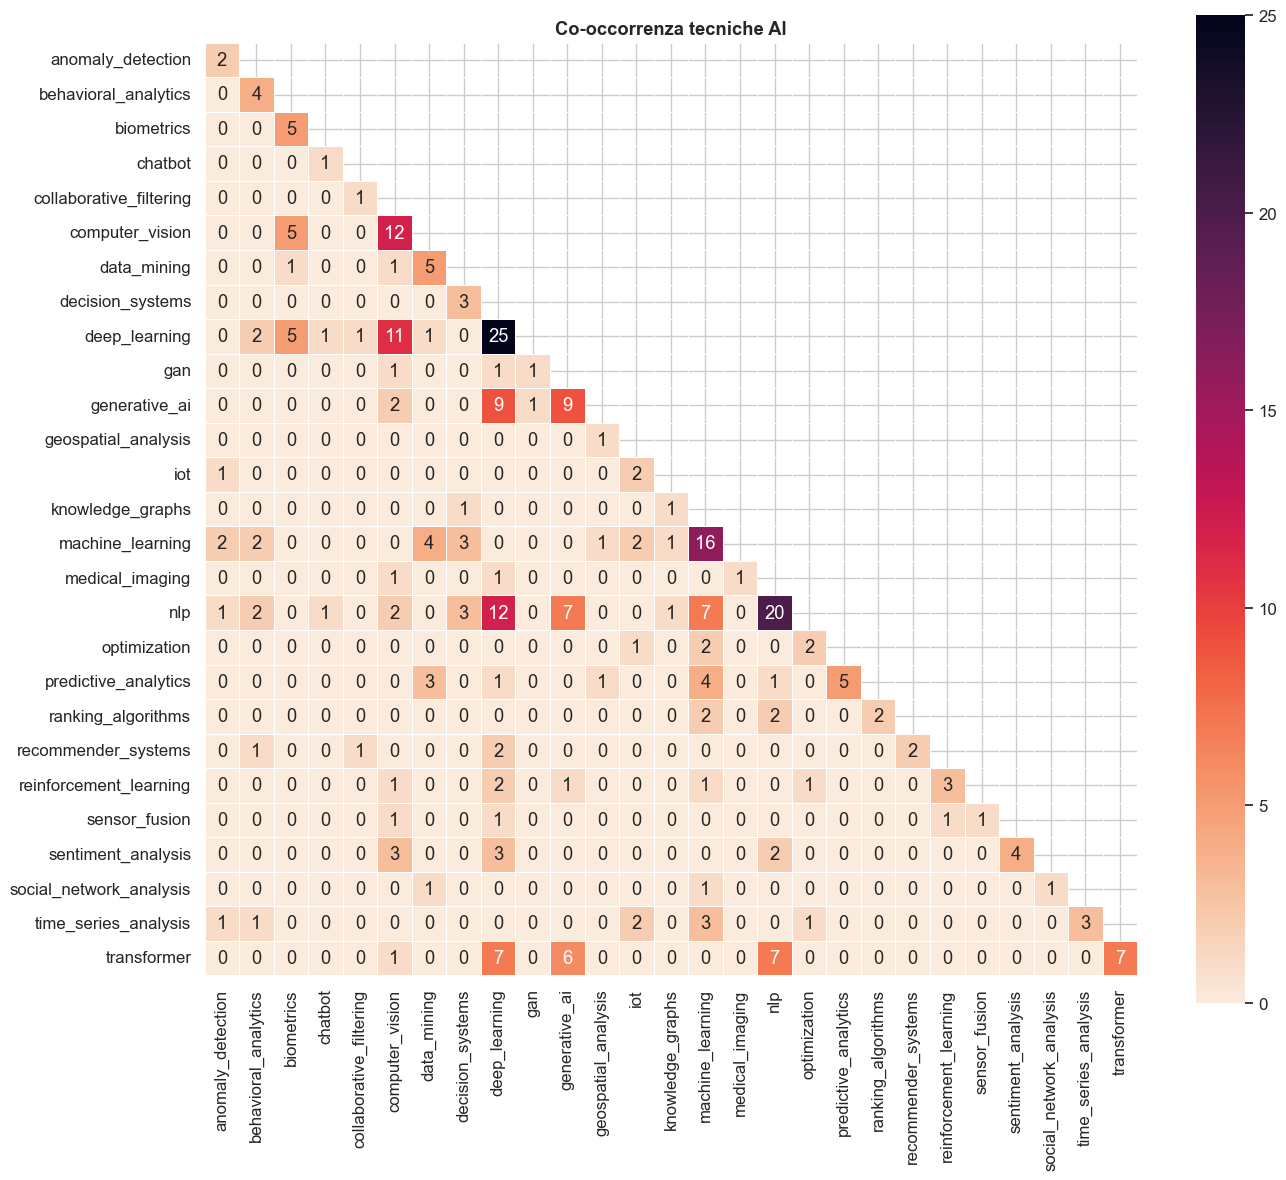

In [14]:
# Heatmap co-occorrenza tecniche
all_techniques = sorted(set(t for techs in df_eu['techniques'] for t in techs))
cooccurrence = pd.DataFrame(0, index=all_techniques, columns=all_techniques)

for techs in df_eu['techniques']:
    for i, t1 in enumerate(techs):
        for t2 in techs[i:]:
            cooccurrence.loc[t1, t2] += 1
            if t1 != t2:
                cooccurrence.loc[t2, t1] += 1

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(cooccurrence, dtype=bool), k=1)
sns.heatmap(cooccurrence, mask=mask, annot=True, fmt='d', cmap='rocket_r',
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Co-occorrenza tecniche AI', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Train/Test Split (pre-augmentation)

Lo split viene eseguito **prima** dell'augmentation per evitare data leakage: nessun testo originale del test set verrà parafrasato nel train set.

In [15]:
# Prepara il dataframe base
df_base = df_eu[["ai_system_name", "use_case", "domain", "app_type", "techniques"]].copy()

# Con 42 righe e ~15 classi, lo split stratificato non è praticabile
# (troppe classi per la dimensione del test set).
# Approccio: split random con seed fisso, poi verifica copertura.

train_split, test_split = train_test_split(
    df_base, test_size=0.1, random_state=RANDOM_STATE
)

df_train_base = train_split.reset_index(drop=True)
df_test_base = test_split.reset_index(drop=True)

print(f"Train (originali): {len(df_train_base)} righe")
print(f"Test (originali):  {len(df_test_base)} righe")
print(f"Ratio test: {len(df_test_base) / len(df_base):.1%}")
print(f"\nClassi nel train: {df_train_base["app_type"].nunique()}")
print(f"Classi nel test:  {df_test_base["app_type"].nunique()}")

Train (originali): 37 righe
Test (originali):  5 righe
Ratio test: 11.9%

Classi nel train: 20
Classi nel test:  3


In [16]:
# Verifica distribuzione train/test
train_dist = df_train_base['app_type'].value_counts().rename('Train')
test_dist = df_test_base['app_type'].value_counts().rename('Test')
split_comparison = pd.concat([train_dist, test_dist], axis=1).fillna(0).astype(int)
split_comparison['Totale'] = split_comparison.sum(axis=1)
split_comparison.sort_values('Totale', ascending=False)

,Train,Test,Totale
app_type,,,
biometrics,4,2,6
general_purpose_ai,5,0,5
employment_ai,3,0,3
law_enforcement,3,0,3
education_ai,2,1,3
healthcare_ai,1,2,3
generative_ai,2,0,2
fintech,2,0,2
recommender_systems,2,0,2


## 6. Data Augmentation (solo train set)

Augmentation template-based: per ogni `use_case` nel train set, generiamo varianti parafrasate che mantengono il significato semantico ma cambiano la struttura sintattica.

In [17]:
def augment_use_case(text, system_name, domain, n_variants=6):
    """Genera parafrasi template-based di un use_case."""
    text_lower = text[0].lower() + text[1:] if text else text
    # Rimuovi punto finale se presente
    text_clean = text.rstrip('.')
    text_lower_clean = text_lower.rstrip('.')
    
    variants = [
        # Variante 1: riformulazione con "AI system that..."
        f"AI system that performs {text_lower_clean}",
        # Variante 2: focus sulla soluzione
        f"An artificial intelligence solution designed for {text_lower_clean}",
        # Variante 3: focus tecnologico
        f"Technology leveraging AI and machine learning for {text_lower_clean}",
        # Variante 4: focus sul dominio
        f"Automated {domain.lower()} application: {text_lower_clean}",
        # Variante 5: descrizione estesa
        f"{text_clean}. This AI-powered system automates key processes in the {domain.lower()} domain",
        # Variante 6: focus sull'impatto
        f"A {domain.lower()} AI tool capable of {text_lower_clean}",
        # Variante 7: prospettiva enterprise
        f"Enterprise AI platform for {text_lower_clean} in {domain.lower()} applications",
        # Variante 8: prospettiva tecnica
        f"Advanced AI system ({system_name}): {text_lower_clean}",
    ]
    
    return variants[:n_variants]


# Genera augmentation per il train set
augmented_rows = []

for _, row in df_train_base.iterrows():
    # Riga originale
    augmented_rows.append({
        'text': row['use_case'],
        'app_type': row['app_type'],
        'techniques': row['techniques'],
        'source': 'original',
    })
    
    # Varianti augmentate
    variants = augment_use_case(row['use_case'], row['ai_system_name'], row['domain'])
    for variant in variants:
        augmented_rows.append({
            'text': variant,
            'app_type': row['app_type'],
            'techniques': row['techniques'],
            'source': 'augmented',
        })

df_train_aug = pd.DataFrame(augmented_rows)

# Shuffle
df_train_aug = df_train_aug.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Train dopo augmentation: {len(df_train_aug)} righe ({len(df_train_base)} originali + {len(df_train_aug) - len(df_train_base)} augmentate)')
print(f'Fattore di espansione: {len(df_train_aug) / len(df_train_base):.1f}x')

Train dopo augmentation: 259 righe (37 originali + 222 augmentate)
Fattore di espansione: 7.0x


In [18]:
# Esempio di augmentation
sample_row = df_train_base.iloc[0]
print(f'Originale: {sample_row["use_case"]}')
print(f'Sistema:   {sample_row["ai_system_name"]}')
print(f'Dominio:   {sample_row["domain"]}')
print(f'\nVarianti generate:')
for i, v in enumerate(augment_use_case(sample_row['use_case'], sample_row['ai_system_name'], sample_row['domain']), 1):
    print(f'  {i}. {v}')

Originale: Multimodal foundation model for search, workspace and developer APIs
Sistema:   Gemini Ultra / Gemini 1.5 Pro
Dominio:   General Purpose AI

Varianti generate:
  1. AI system that performs multimodal foundation model for search, workspace and developer APIs
  2. An artificial intelligence solution designed for multimodal foundation model for search, workspace and developer APIs
  3. Technology leveraging AI and machine learning for multimodal foundation model for search, workspace and developer APIs
  4. Automated general purpose ai application: multimodal foundation model for search, workspace and developer APIs
  5. Multimodal foundation model for search, workspace and developer APIs. This AI-powered system automates key processes in the general purpose ai domain
  6. A general purpose ai AI tool capable of multimodal foundation model for search, workspace and developer APIs


## 7. Costruzione Dataset Finali

=== Model 1 (Multiclass) ===
Train: 259 righe, 20 classi
Test:  5 righe, 3 classi


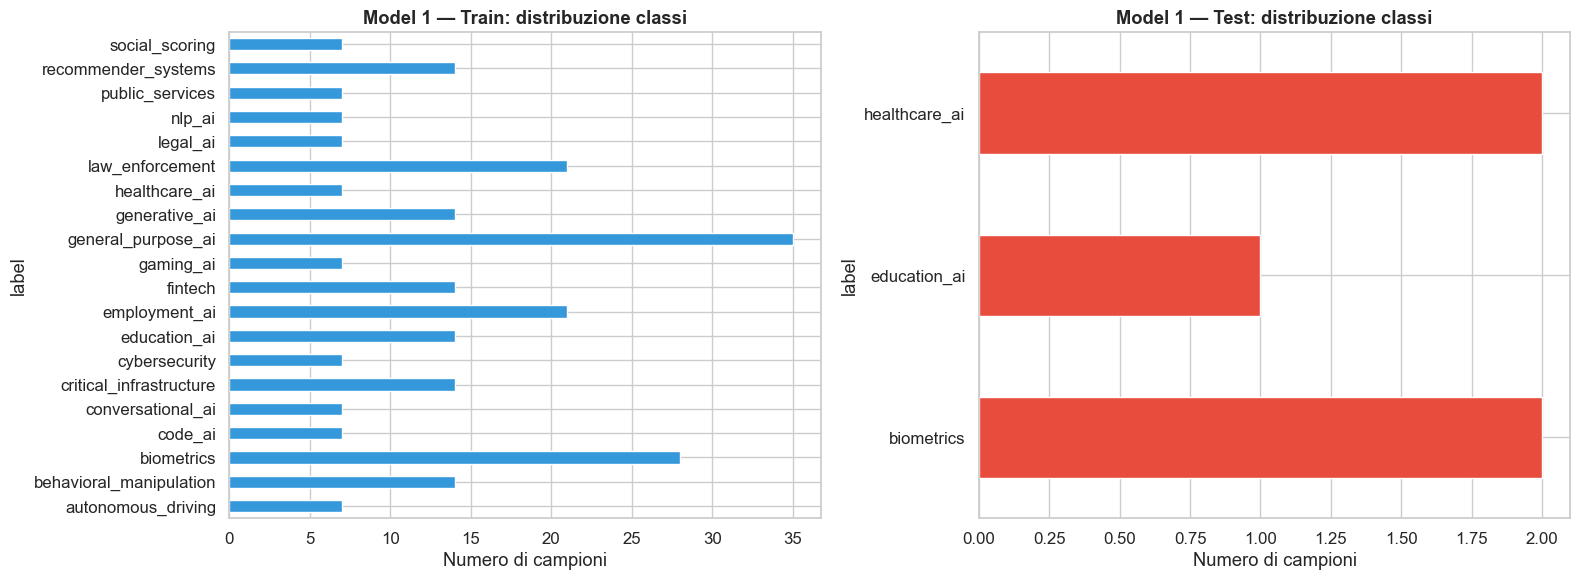

In [19]:
# ============================================================
# MODEL 1 — Multiclass: text + label
# ============================================================

train_m1 = df_train_aug[['text', 'app_type']].rename(columns={'app_type': 'label'})
test_m1 = df_test_base[['use_case', 'app_type']].rename(columns={'use_case': 'text', 'app_type': 'label'})

print('=== Model 1 (Multiclass) ===')
print(f'Train: {len(train_m1)} righe, {train_m1["label"].nunique()} classi')
print(f'Test:  {len(test_m1)} righe, {test_m1["label"].nunique()} classi')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

train_m1['label'].value_counts().sort_index().plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Model 1 — Train: distribuzione classi', fontweight='bold')
axes[0].set_xlabel('Numero di campioni')

test_m1['label'].value_counts().sort_index().plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Model 1 — Test: distribuzione classi', fontweight='bold')
axes[1].set_xlabel('Numero di campioni')

plt.tight_layout()
plt.show()

=== Model 2 (Multilabel) ===
Train: 259 righe, 26 tecniche
Test:  5 righe, 10 tecniche
Media label per campione (train): 3.3
Media label per campione (test):  3.2


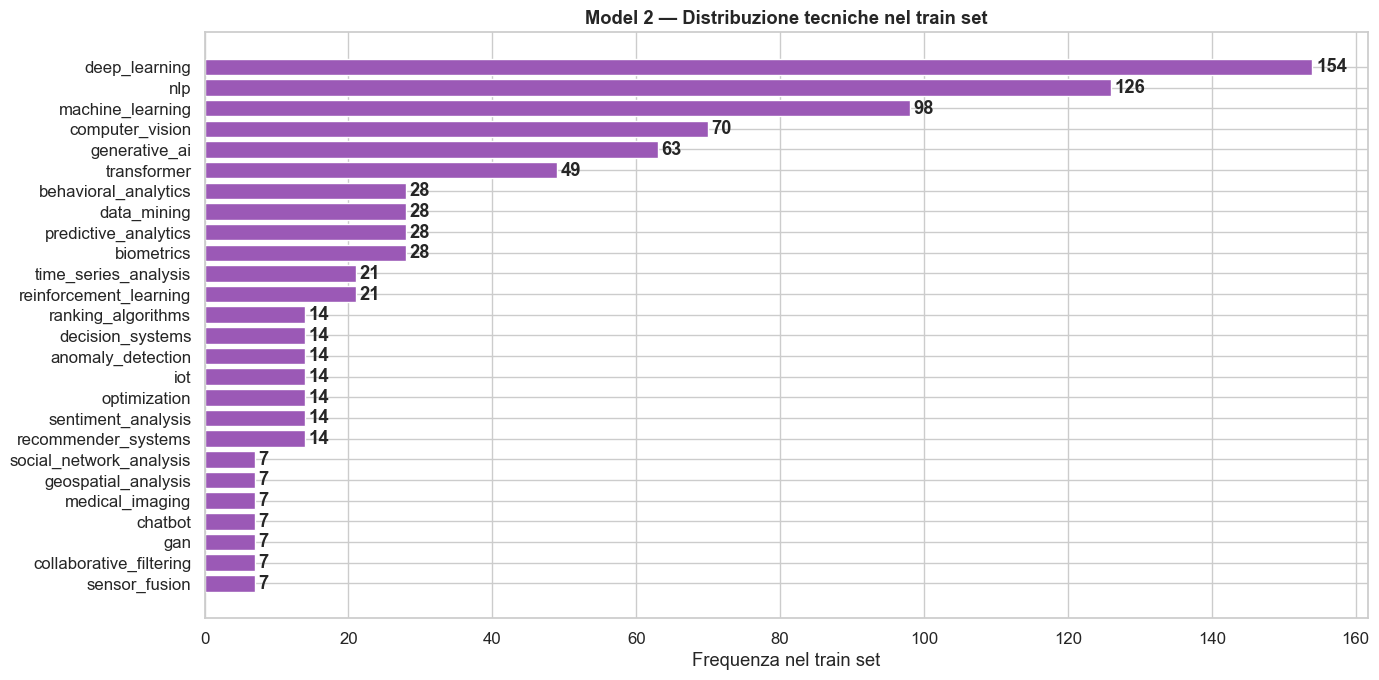

In [20]:
# ============================================================
# MODEL 2 — Multilabel: text + labels (lista)
# ============================================================

train_m2 = df_train_aug[['text', 'techniques']].rename(columns={'techniques': 'labels'})
test_m2 = df_test_base[['use_case', 'techniques']].rename(columns={'use_case': 'text', 'techniques': 'labels'})

# Conteggio label nel train
train_tech_counter = Counter(t for labels in train_m2['labels'] for t in labels)
test_tech_counter = Counter(t for labels in test_m2['labels'] for t in labels)

print('=== Model 2 (Multilabel) ===')
print(f'Train: {len(train_m2)} righe, {len(train_tech_counter)} tecniche')
print(f'Test:  {len(test_m2)} righe, {len(test_tech_counter)} tecniche')
print(f'Media label per campione (train): {np.mean([len(l) for l in train_m2["labels"]]):.1f}')
print(f'Media label per campione (test):  {np.mean([len(l) for l in test_m2["labels"]]):.1f}')

# Distribuzione label
fig, ax = plt.subplots(figsize=(14, 7))
train_tech_df = pd.DataFrame(train_tech_counter.most_common(), columns=['Tecnica', 'Frequenza'])
ax.barh(train_tech_df['Tecnica'][::-1], train_tech_df['Frequenza'][::-1], color='#9b59b6')
ax.set_xlabel('Frequenza nel train set')
ax.set_title('Model 2 — Distribuzione tecniche nel train set', fontweight='bold')
for i, v in enumerate(train_tech_df['Frequenza'][::-1]):
    ax.text(v + 0.5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Salvataggio Output

In [21]:
# ============================================================
# JSONL — formato ottimale per HuggingFace datasets
# ============================================================

# Model 1: {"text": "...", "label": "fintech"}
train_m1.to_json(PROCESSED_DIR / 'model1_multiclass_train.jsonl',
                 orient='records', lines=True, force_ascii=False)
test_m1.to_json(PROCESSED_DIR / 'model1_multiclass_test.jsonl',
                orient='records', lines=True, force_ascii=False)

# Model 2: {"text": "...", "labels": ["nlp", "deep_learning"]}
train_m2.to_json(PROCESSED_DIR / 'model2_multilabel_train.jsonl',
                 orient='records', lines=True, force_ascii=False)
test_m2.to_json(PROCESSED_DIR / 'model2_multilabel_test.jsonl',
                orient='records', lines=True, force_ascii=False)

print('File JSONL salvati:')
for f in sorted(PROCESSED_DIR.glob('*.jsonl')):
    size = f.stat().st_size
    print(f'  {f.name} ({size:,} bytes)')

File JSONL salvati:
  model1_multiclass_test.jsonl (488 bytes)
  model1_multiclass_train.jsonl (37,013 bytes)
  model2_multilabel_test.jsonl (694 bytes)
  model2_multilabel_train.jsonl (47,009 bytes)


In [22]:
# ============================================================
# CSV — per ispezione manuale
# ============================================================

# Model 1
train_m1.to_csv(PROCESSED_DIR / 'model1_multiclass_train.csv', index=False)
test_m1.to_csv(PROCESSED_DIR / 'model1_multiclass_test.csv', index=False)

# Model 2 — converti labels lista in stringa per CSV
train_m2_csv = train_m2.copy()
train_m2_csv['labels'] = train_m2_csv['labels'].apply(lambda x: '|'.join(x))
test_m2_csv = test_m2.copy()
test_m2_csv['labels'] = test_m2_csv['labels'].apply(lambda x: '|'.join(x))

train_m2_csv.to_csv(PROCESSED_DIR / 'model2_multilabel_train.csv', index=False)
test_m2_csv.to_csv(PROCESSED_DIR / 'model2_multilabel_test.csv', index=False)

print('File CSV salvati:')
for f in sorted(PROCESSED_DIR.glob('*.csv')):
    size = f.stat().st_size
    print(f'  {f.name} ({size:,} bytes)')

File CSV salvati:
  model1_multiclass_test.csv (394 bytes)
  model1_multiclass_train.csv (31,656 bytes)
  model2_multilabel_test.csv (564 bytes)
  model2_multilabel_train.csv (39,672 bytes)


In [23]:
# ============================================================
# Label config — metadata per riproducibilità
# ============================================================

all_techniques_sorted = sorted(set(t for techs in df_eu['techniques'] for t in techs))

label_config = {
    'model1': {
        'task': 'multiclass',
        'classes': sorted(df_eu['app_type'].unique().tolist()),
        'num_classes': df_eu['app_type'].nunique(),
        'domain_to_label': DOMAIN_TO_LABEL,
    },
    'model2': {
        'task': 'multilabel',
        'labels': all_techniques_sorted,
        'num_labels': len(all_techniques_sorted),
        'system_to_techniques': SYSTEM_TO_TECHNIQUES,
    },
    'split': {
        'test_size': 0.1,
        'random_state': RANDOM_STATE,
        'strategy': 'stratified on app_type, split before augmentation',
        'augmentation': 'template-based, 6 variants per sample (train only)',
    },
    'source': 'eu_ai_act_risk_register_2026.csv',
    'total_original_samples': len(df_eu),
    'train_original': len(df_train_base),
    'train_augmented': len(df_train_aug),
    'test_samples': len(df_test_base),
}

with open(PROCESSED_DIR / 'label_config.json', 'w', encoding='utf-8') as f:
    json.dump(label_config, f, indent=2, ensure_ascii=False)

print('label_config.json salvato')
print(json.dumps(label_config, indent=2, ensure_ascii=False)[:500] + '\n...')

label_config.json salvato
{
  "model1": {
    "task": "multiclass",
    "classes": [
      "autonomous_driving",
      "behavioral_manipulation",
      "biometrics",
      "code_ai",
      "conversational_ai",
      "critical_infrastructure",
      "cybersecurity",
      "education_ai",
      "employment_ai",
      "fintech",
      "gaming_ai",
      "general_purpose_ai",
      "generative_ai",
      "healthcare_ai",
      "law_enforcement",
      "legal_ai",
      "nlp_ai",
      "public_services",
      "recommender_sy
...


## 9. Verifica e Riepilogo

In [24]:
# Verifica data leakage
train_texts = set(df_train_base['use_case'].tolist())
test_texts = set(df_test_base['use_case'].tolist())
overlap = train_texts & test_texts
print(f'Data leakage check: {len(overlap)} testi originali in comune tra train e test')
assert len(overlap) == 0, 'DATA LEAKAGE DETECTED!'
print('✓ Nessun data leakage\n')

# Verifica formato JSONL
with open(PROCESSED_DIR / 'model1_multiclass_train.jsonl') as f:
    first_line = json.loads(f.readline())
    assert 'text' in first_line and 'label' in first_line
print(f'✓ Model 1 JSONL valido. Esempio: {first_line}')

with open(PROCESSED_DIR / 'model2_multilabel_train.jsonl') as f:
    first_line = json.loads(f.readline())
    assert 'text' in first_line and 'labels' in first_line
    assert isinstance(first_line['labels'], list)
print(f'✓ Model 2 JSONL valido. Esempio: {{"text": "{first_line["text"][:60]}...", "labels": {first_line["labels"]}}}')

# Riepilogo finale
print(f'\n{"="*60}')
print(f'{"RIEPILOGO":^60}')
print(f'{"="*60}')
print(f'{"":20} {"Model 1 (Multiclass)":>20} {"Model 2 (Multilabel)":>20}')
print(f'{"─"*60}')
print(f'{"Train samples":20} {len(train_m1):>20} {len(train_m2):>20}')
print(f'{"Test samples":20} {len(test_m1):>20} {len(test_m2):>20}')
print(f'{"Classi/Label":20} {train_m1["label"].nunique():>20} {len(all_techniques_sorted):>20}')
print(f'{"Formato":20} {"JSONL + CSV":>20} {"JSONL + CSV":>20}')
print(f'{"Output dir":20} {"data/processed/":>20} {"data/processed/":>20}')
print(f'{"="*60}')

Data leakage check: 0 testi originali in comune tra train e test
✓ Nessun data leakage

✓ Model 1 JSONL valido. Esempio: {'text': 'Technology leveraging AI and machine learning for monitoring worker behavior and scoring productivity for management decisions', 'label': 'employment_ai'}
✓ Model 2 JSONL valido. Esempio: {"text": "Technology leveraging AI and machine learning for monitoring...", "labels": ['machine_learning', 'behavioral_analytics', 'time_series_analysis']}

                         RIEPILOGO                          
                     Model 1 (Multiclass) Model 2 (Multilabel)
────────────────────────────────────────────────────────────
Train samples                         259                  259
Test samples                            5                    5
Classi/Label                           20                   27
Formato                       JSONL + CSV          JSONL + CSV
Output dir                data/processed/      data/processed/
